# Screening fixes for model-agreement false alarms (iteration-5 FREEZE, Part A demo)

**Context.** This work measures whether an NL→FOL formalization is *faithful* to its sentence **without a gold formula**.
The frozen baseline metric **V0 = `c_score_align`** asks: *how many other systems' formalizations of the same sentence
disagree with this candidate?* (a pairwise solver-checked "equivalent-modulo-vocabulary" matrix across ~9 model families).
A high value means the candidate is probably an **ERROR**.

V0 has a known failure pattern called a **model-agreement false alarm**: correct candidates that phrase things at a different
granularity get flagged (the false-alarm rate `d`), while wrong candidates that the majority shares get endorsed (the
error-endorsement rate `e`). The experiment pre-registered five **label-free rescorings** of V0 and screened them on dataset E:

| variant | idea |
|---|---|
| V1 | plurality-normalised agreement |
| V2 | reliability-weighted peers (out-of-fold family weights) |
| V3 | V1 + V2 |
| V4 | cross-fitted logistic on (c_exact, V0) |
| V5 | V3 restricted to a 3-family peer pool |

plus **GG** (gloss-gated name-free agreement: z3 equivalence under an injective symbol map whose renamings an LLM checker accepts).

**What `method.py` is.** The original `method.py` is an *orchestrator*: it runs ~25 `src/` scripts in a pre-registered order
(the variant scores themselves were computed from eval-2's pairwise matrix and sealed before any label join; the GG search
needs z3 and paid OpenRouter calls). This notebook:

1. shows the orchestrator verbatim (as a dry run — the upstream inputs are not shipped),
2. then runs the **label-side core of Part A** — the statistics (`src/stats.py`), the screen (`src/screen.py`: AUROC per cell,
   paired Δ vs V0 with sentence-cluster bootstrap CIs, false-alarm `d` / error-endorsement `e`), and the pre-registered selection
   rule with its stability and permutation-null checks (`src/select_rule.py`) — on a 100-row labelled subset of the sealed scores
   published in `full_method_out.json`.

Full-run result (2,672 rows): **"NONE: V0 stands"** — no variant beats V0 by the required +0.015 LONG-strat AUROC, and no variant
lowers `d` without raising `e`. On 100 rows the numbers are noisier; the notebook prints the full-run values next to the demo values.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (method.py's logger)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- method.py imports (verbatim) ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- src/stats.py, src/screen.py, src/select_rule.py, src/labels.py imports ---
import json
import math
from collections import Counter, defaultdict
from typing import Sequence

import numpy as np
import pandas as pd
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression

# --- notebook-only: visualisation ---
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
EX = data["datasets"][0]["examples"]
print(data["metadata"]["demo_note"])
print(len(EX), "rows;", Counter(e["output"] for e in EX))
print(json.dumps(EX[0], indent=1)[:1200])

100 labelled rows of the Z population (E_heldout, in_Z=True): 25 per stratum (L25/L20/EXC/CTRL), <=3 rows per sentence, seed 0. Full Z = 2,672 rows / 283 sentences.
100 rows; Counter({'CORRECT': 61, 'ERROR': 39})
{
 "input": "{\"text\": \"A game played on a rectangular field, involving two opposing teams, and requiring the use of a spherical ball to score goals is a soccer match.\", \"candidate_fol\": \"\u2200x ((Game(x) \u2227 PlayedOnRectangularField(x) \u2227 InvolvesTwoOpposingTeams(x) \u2227 RequiresSphericalBallToScoreGoals(x)) \u2192 SoccerMatch(x))\", \"system\": \"F:openai/gpt-5.1\", \"prompt_variant\": \"fewshot_v1\"}",
 "output": "CORRECT",
 "predict_V0": "0.818182",
 "predict_V0_rep": "0.818182",
 "predict_V1": "0.333333",
 "predict_V2": "0.828696",
 "predict_V3": "0.386897",
 "predict_V4": "0.726019",
 "predict_V5": "1",
 "predict_c_exact": "0.909091",
 "predict_gg": "0.909091",
 "predict_gg_allyes": "0.818182",
 "predict_p_peer_text": "0.637794",
 "predict_judge_cheap_dis

## Config

All tunable parameters. The original run used `B = 2000` sentence-cluster bootstrap replicates (`src/common.py`),
`500` within-stratum stability resamples and `200` permutation-null replicates (`src/select_rule.py`), on all 2,672 rows of Z.
The selection-rule constants (`MARGIN`, `L25_TOL`, `CTRL_TOL`, `TIE`) are **pre-registered** and must not be tuned.

In [5]:
# ---- demo scale: bootstrap/stability/null counts are the ORIGINAL values; only N_ROWS is reduced ----
N_ROWS = 100      # rows of Z used (mini_demo_data.json holds 100; original: 2672 = all of Z)
B = 2000          # sentence-cluster bootstrap replicates for CIs (= original)
B_STAB = 500      # selection-stability resamples (= original)
B_NULL = 200      # permutation-null replicates (= original)
SEED = 20260924   # src/common.py SEED (bootstrap); stability uses SEED+1, null SEED+2

# ---- pre-registered selection rule (src/select_rule.py; do NOT change) ----
MARGIN, L25_TOL, CTRL_TOL, TIE = 0.015, 0.0, 0.01, 1e-4

# ---- orchestrator (method.py CLI args, now plain variables) ----
STAGES = "A,B,GGB,C,OUT,TEST"   # --stage
FORCE = False                   # --force
RUN_PIPELINE = False            # notebook-only: the src/ scripts and upstream inputs are not shipped -> dry run

## 1. The orchestrator (`method.py`)

`STEPS` is the pre-registered order of the whole experiment: `(stage, script + args, cwd, marker output)`. A step whose
marker already exists is skipped, so re-running never re-bills OpenRouter and never rewrites a frozen file
(`NEVER_FORCE` writers refuse to overwrite even with `--force`).

* **A** — Part A screen: gates G0/G1 → pre-registration → label-free scoring of V1–V5 (sealed by sha256) → V4 cross-fit →
  screen → selection rule → freeze.
* **B** — Part B GG: probe → pre-registration → exhaustive symbol-map search (z3) → checker gates → LLM gloss → scoring → freeze.
* **GGB** — secondary GG_B search/score; **C** — vendored library; **OUT** — outputs/tables; **TEST** — pytest + audits.

Code is verbatim except: `ROOT` uses the notebook's cwd (no `__file__`), argparse is replaced by the config variables, and
a `RUN_PIPELINE` guard turns the subprocess call into a dry-run print.

In [6]:
ROOT = Path.cwd()          # original: Path(__file__).resolve().parent
SRC = ROOT / "src"
PY = sys.executable

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

# (stage, script + args, cwd, output that marks the step done)
STEPS = [
    ("A", ["copy_inputs.py"], SRC, "inputs_manifest.json"),
    ("A", ["step0_gates.py"], SRC, "results/gate_G0.json"),
    ("A", ["prereg_improve.py"], SRC, "prereg_improve.json"),
    ("A", ["make_row_index.py"], SRC, "results/row_index_labelfree.jsonl"),
    ("A", ["score_variants.py"], SRC, "results/scores_E_variants.jsonl"),
    ("A", ["fit_v4.py"], SRC, "results/scores_E_V4.jsonl"),
    ("A", ["screen.py"], SRC, "results/screen_E.json"),
    ("A", ["select_rule.py"], SRC, "results/selection_E.json"),
    ("A", ["freeze_part_a.py"], SRC, "freeze/selection.json"),
    ("B", ["probe.py"], SRC, "results/probe.json"),
    ("B", ["prereg_gg.py"], SRC, "prereg_gg.json"),
    ("B", ["gg_search.py", "all"], SRC, "results/gg_search.jsonl"),
    ("B", ["gg_gates.py", "dev", "v1"], SRC, "results/gg_gates_dev_v1.json"),
    ("B", ["gg_gates.py", "confirm", "v2"], SRC, "results/gg_gates_confirm_v2.json"),
    ("B", ["gg_gloss.py"], SRC, "results/gg_verdicts.json"),
    ("B", ["gg_score.py"], SRC, "results/gg_dev.json"),
    ("B", ["freeze_part_b.py"], SRC, "freeze/gg_gate.json"),
    ("GGB", ["ggb_search.py", "all"], SRC, "results/ggb_search.jsonl"),
    ("GGB", ["ggb_score.py"], SRC, "results/ggb_dev.json"),
    ("C", ["vendor_lib.py"], SRC, "lib/PROVENANCE.json"),
    ("OUT", ["make_outputs.py"], SRC, "method_out.json"),
    ("OUT", ["make_tables.py"], SRC, "tables.md"),
    ("TEST", ["-m", "pytest", "-q", "tests/test_variants.py", "tests/test_gg.py", "tests/test_budget.py"], ROOT, None),
    ("TEST", ["tests/audit_rederive.py"], ROOT, None),
    ("TEST", ["tests/smoke_lib.py"], ROOT, None),
]
NEVER_FORCE = {"prereg_improve.py", "prereg_gg.py", "freeze_part_a.py"}  # immutable writers


def main():
    stages = set(STAGES.split(","))           # original: argparse --stage
    env = {**os.environ, "PYTHONHASHSEED": "0"}
    for stage, args, cwd, marker in STEPS:
        if stage not in stages:
            continue
        name = args[0]
        if marker and (ROOT / marker).exists() and (not FORCE or name in NEVER_FORCE):
            logger.info(f"[{stage}] skip {' '.join(args)} ({marker} exists)")
            continue
        if not RUN_PIPELINE:                  # notebook-only guard
            logger.info(f"[{stage}] (dry run) would run {' '.join(args)} -> {marker}")
            continue
        logger.info(f"[{stage}] run {' '.join(args)}")
        t0 = time.time()
        try:
            subprocess.run([PY, *args], cwd=cwd, env=env, check=True)
        except subprocess.CalledProcessError as e:
            logger.error(f"[{stage}] {name} failed with exit code {e.returncode}")
            raise
        logger.info(f"[{stage}] {name} done in {time.time() - t0:.0f}s")


main()

16:51:47|INFO   |[A] (dry run) would run copy_inputs.py -> inputs_manifest.json


16:51:47|INFO   |[A] (dry run) would run step0_gates.py -> results/gate_G0.json


16:51:47|INFO   |[A] (dry run) would run prereg_improve.py -> prereg_improve.json


16:51:47|INFO   |[A] (dry run) would run make_row_index.py -> results/row_index_labelfree.jsonl


16:51:47|INFO   |[A] (dry run) would run score_variants.py -> results/scores_E_variants.jsonl


...

16:51:47|INFO   |[OUT] (dry run) would run make_outputs.py -> method_out.json


16:51:47|INFO   |[OUT] (dry run) would run make_tables.py -> tables.md


16:51:47|INFO   |[TEST] (dry run) would run -m pytest -q tests/test_variants.py tests/test_gg.py tests/test_budget.py -> None


16:51:47|INFO   |[TEST] (dry run) would run tests/audit_rederive.py -> None


16:51:47|INFO   |[TEST] (dry run) would run tests/smoke_lib.py -> None


## 2. Statistics (`src/stats.py`)

**Part 1** (copied unchanged from experiment 6): Mann–Whitney `auroc`, the **within-stratum AUROC** `strat_auroc`
(only (ERROR, CORRECT) pairs from the same source stratum count — this removes the effect of stratum composition), and a
sentence-clustered bootstrap. **Part 2** (from evaluation 2): the same bootstrap as a matrix of *multiplicity weights*
`W[b, i]` = how many times row *i*'s sentence was drawn in replicate *b*, which makes every Δ paired and fast.

In [7]:
# ============================================================ Part 1: exp 6 api_bar.py (verbatim)
def auroc(y, s) -> float:
    """Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auroc(y, s, stratum) -> float:
    """Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC."""
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    """Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired."""

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    """Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`)."""
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


# ============================================================ Part 2: eval-2 stats.py weighted forms (verbatim)
class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b."""

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def W(self, mask=None):
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


# ============================================================ vectorised helpers (this artifact)
def boot_series(y, s, strata, W, stat: str = "strat") -> np.ndarray:
    """Replicate values of (strat|pooled) AUROC under a (B, n) weight matrix."""
    f = WStratAuc(y, s, strata) if stat == "strat" else WAuc(y, s)
    return np.array([f(w) for w in W])


def point(y, s, strata, stat: str = "strat") -> float:
    return strat_auroc(y, s, strata) if stat == "strat" else auroc(y, s)


def rate_ci(num_mask, den_mask, W) -> list:
    """CI of a ratio sum(w*num)/sum(w*den) over replicates."""
    with np.errstate(invalid="ignore", divide="ignore"):
        v = (W @ num_mask.astype(float)) / (W @ den_mask.astype(float))
    return boot_ci(v)

## 3. Labels and the analysis frame (`src/labels.py`)

Error-type classes: `op_class` groups perturbation/error operations into COVERAGE (ADD/DROP), POLARITY (NEG/REV/QUANT) and
STRUCT; `t9_classes` gives the six reporting classes used for per-error-type `e`.

`frame()` originally joined the sealed score file with the label file after checking the sha256 seal. Here the same
columns are rebuilt from the published per-row output (`predict_*` columns = sealed scores, `output` = label). The only
missing input is exp 9's `auto_label` (tier-B `VOCAB_GRAN`), so the MEANING_RENAME-type class counts only explicit
`MEANING_RENAME` ops. All `predict_*` scores are oriented **higher = more likely ERROR**.

In [8]:
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}
T9 = ["ADD", "DROP", "COMPOUND", "polarity(NEG/REV/QUANT)", "structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)",
      "MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)"]
STRATA = ("L25", "L20", "EXC", "CTRL")
LONG = ("L25", "L20", "EXC")


def op_class(ops) -> str:
    """eval-2 vendor_exp5/vendor_c/common.py op_class (verbatim)."""
    ops = list(ops) if ops is not None and not isinstance(ops, float) else []
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


def t9_classes(error_ops, auto_label) -> list[str]:
    """exp 9 src/analyse.py (e) classes(r), verbatim logic."""
    ops = set(error_ops or [])
    out = []
    if "ADD" in ops: out.append("ADD")
    if "DROP" in ops: out.append("DROP")
    if "COMPOUND" in ops: out.append("COMPOUND")
    if ops & {"NEG", "REV", "QUANT"}: out.append("polarity(NEG/REV/QUANT)")
    if ops & {"CONN", "RESTR", "BIND", "MOVE", "SWAP", "SCOPE", "UNGLUE"}: out.append("structural(CONN/RESTR/BIND/MOVE/SWAP/SCOPE/UNGLUE)")
    if "MEANING_RENAME" in ops or auto_label == "VOCAB_GRAN": out.append("MEANING_RENAME-type (MEANING_RENAME op or tier-B VOCAB_GRAN)")
    return out


def frame() -> pd.DataFrame:
    """Notebook version: rebuild the post-seal frame from the demo rows (original joined scores_E_variants.jsonl with
    per_item_T1.jsonl after check_seal())."""
    rows = []
    for e in EX[:N_ROWS]:
        inp = json.loads(e["input"])
        rows.append({"row_key": e["metadata_row_key"], "sentence_id": e["metadata_sentence_id"], "stratum": e["metadata_stratum"],
                     "fold": e["metadata_fold"], "R_AB": e["metadata_in_R_AB"], "Z": e["metadata_in_Z"], "y_R_AB": e["metadata_y_R_AB"],
                     "words": e["metadata_words"], "n_conditions": e["metadata_n_conditions"], "n_peers": e["metadata_n_peers"],
                     "error_ops": e["metadata_error_ops"], "auto_label": None, "family": e["metadata_family"],
                     "text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                     "V0_frozen": e["predict_V0"], "V0_rep": e["predict_V0_rep"], "c_exact": e["predict_c_exact"],
                     "V1": e["predict_V1"], "V2": e["predict_V2"], "V3": e["predict_V3"], "V4": e["predict_V4"], "V5": e["predict_V5"],
                     "gg": e["predict_gg"], "judge_cheap_disg": e["predict_judge_cheap_disg"], "p_peer_text": e["predict_p_peer_text"]})
    df = pd.DataFrame(rows)
    for c in ["V0_frozen", "V0_rep", "c_exact", "V1", "V2", "V3", "V4", "V5", "gg", "judge_cheap_disg", "p_peer_text"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")   # 'NA' -> NaN
    # ---- from here on: original labels.frame() column logic ----
    df["y"] = df.y_R_AB
    df["long"] = df.stratum.isin(["L25", "L20", "EXC"])
    df["words_t"] = np.where(df.words <= 20, "T1", np.where(df.words <= 26, "T2", "T3"))
    df["t9"] = [t9_classes(o, a) if y == 1 else [] for o, a, y in zip(df.error_ops, df.auto_label, df.y)]
    df["opc"] = [op_class(o) for o in df.error_ops]
    return df


df = frame()
print(df.groupby(["stratum", "y"]).size().unstack(), "\n")
print("words tercile:", Counter(df.words_t), "| sentences:", df.sentence_id.nunique())
df[["stratum", "system", "y", "V0_frozen", "V1", "V2", "V4", "text", "candidate_fol"]].head(6)

y         0   1
stratum        
CTRL     16   9
EXC      17   8
L20      14  11
L25      14  11 

words tercile: Counter({'T1': 43, 'T2': 35, 'T3': 22}) | sentences: 37


,stratum,system,y,V0_frozen,V1,V2,V4,text,candidate_fol
0,L25,F:openai/gpt-5.1,0,0.818182,0.333333,0.828696,0.726019,"A game played on a rectangular field, involvin...",∀x ((Game(x) ∧ PlayedOnRectangularField(x) ∧ I...
1,L25,G2:qwen/qwen3-235b-a22b-2507,0,0.818182,0.500000,0.811637,0.726019,"A game played on a rectangular field, involvin...",∀x (Game(x) ∧ PlayedOnRectangularField(x) ∧ In...
2,L25,G5:google/gemma-3-27b-it,1,0.909091,0.666667,0.899919,0.754197,"A game played on a rectangular field, involvin...","∀x ((Game(x) ∧ PlayedOn(x, rectangularField) ∧..."
3,L25,G4:deepseek/deepseek-v3.2,0,1.000000,1.000000,1.000000,0.834214,"In an orchestra, string instruments produce so...","∀x ((StringInstrument(x) ∧ In(x, orchestra)) →..."
4,L25,G9:cohere/command-r7b-12-2024,1,1.000000,1.000000,1.000000,0.834214,"In an orchestra, string instruments produce so...","∀x (StringInstrument(x) → SoundProduction(x, v..."
5,L25,G8:google/gemini-2.5-flash,1,1.000000,1.000000,1.000000,0.834214,"In an orchestra, string instruments produce so...","∀x (StringInstrument(x) → ProducesSoundBy(x, v..."


## 4. The screen (`src/screen.py`)

* `flags`: a binary ERROR flag per score is `c > 0.5`; V4 (a probability, not an agreement share) is thresholded at the value
  that matches V0's flag rate, so the comparison is at equal flagging budget.
* `auc_block`: point AUROC + bootstrap replicate series under the weight matrix.
* `ed_block`: **e** = error endorsement (share of ERROR rows *not* flagged), **d** = false alarm (share of CORRECT rows
  flagged), with bootstrap CIs; `auroc_b = 1 - (e + d)/2` is the balanced accuracy of the binary flag.

Cells: `ALL-strat` and `LONG-strat` (within-stratum AUROC), `pooled`, and one pooled AUROC per stratum
(`L25` = ≥25 words, `L20` = 20–24 words, `EXC` = sentences with exceptions, `CTRL` = short controls).

In [9]:
VARIANTS = ["V1", "V2", "V3", "V4", "V5"]
SCORES = ["V0_frozen", "V0_rep", "c_exact"] + VARIANTS
JUDGES = ["judge_cheap_disg"]   # original also had judge_cheap_orig / judge_cheap2_orig (not in the published rows)
CELLS = {"ALL-strat": (None, "strat"), "pooled": (None, "pooled"), "LONG-strat": (LONG, "strat"),
         "L25": (("L25",), "pooled"), "L20": (("L20",), "pooled"), "EXC": (("EXC",), "pooled"), "CTRL": (("CTRL",), "pooled")}


def flags(df: pd.DataFrame, P: pd.DataFrame) -> dict:
    """Binary flag per score: c > 0.5; V4 at the threshold matching V0's flag rate on Z (ties broken by row order)."""
    out = {s: (P[s].astype(float).values > 0.5) for s in SCORES if s != "V4"}
    rate = out["V0_frozen"].mean()
    v = P["V4"].astype(float).values
    thr = float(np.quantile(v, 1 - rate, method="higher"))
    f4 = v > thr
    if abs(f4.mean() - rate) > 0.01:  # step ties: take the top-k by score (stable by row order)
        k = int(round(rate * len(v)))
        o = np.argsort(-v, kind="stable")
        f4 = np.zeros(len(v), bool)
        f4[o[:k]] = True
    out["V4"] = f4
    out["_V4_threshold"] = thr
    out["_V0_flag_rate"] = float(rate)
    return out


def auc_block(y, s, st, W, stat):
    pt = strat_auroc(y, s, st) if stat == "strat" else auroc(y, s)
    f = WStratAuc(y, s, st) if stat == "strat" else WAuc(y, s)
    bs = np.array([f(w) for w in W])
    return pt, bs


def ed_block(y, fl, W) -> dict:
    y = np.asarray(y, int)
    endorsed = ~fl
    e = float(endorsed[y == 1].mean()) if (y == 1).any() else None
    d = float(fl[y == 0].mean()) if (y == 0).any() else None
    with np.errstate(invalid="ignore", divide="ignore"):
        eb = (W @ (endorsed & (y == 1)).astype(float)) / (W @ (y == 1).astype(float))
        db = (W @ (fl & (y == 0)).astype(float)) / (W @ (y == 0).astype(float))
    return {"e": e, "d": d, "e_ci": boot_ci(eb), "d_ci": boot_ci(db), "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()),
            "auroc_b": (1 - (e + d) / 2) if e is not None and d is not None else None, "_eb": eb, "_db": db}

### 4a. AUROC per cell and paired Δ vs frozen V0

Body of `screen.main()` (population → AUROC per cell → Δ vs V0 → Δ vs judge). Dropped vs the original: the
`assert len(P) == 2672` and the reproduction targets that only hold on the full Z, and the file writes.

In [10]:
t0 = time.time()
P = df[df.Z].reset_index(drop=True)
P["V0_frozen"] = P.V0_frozen.astype(float)
y = P.y.values.astype(int)
st = P.stratum.values
boot = SentBoot(P.sentence_id.values, b=B, seed=SEED)
Wf = boot.W()
A = {"population": {"Z": {"n": len(P), "n_error": int(y.sum()), "n_correct": int((1 - y).sum()), "n_sentences": int(P.sentence_id.nunique())}},
     "B": B, "seed": SEED}
# ---------------- AUROC per cell
A["auroc"], A["delta_vs_V0"], A["delta_vs_judges"] = {}, {}, {}
rows_auc, rows_d = [], []
for cname, (strata, stat) in CELLS.items():
    m = np.ones(len(P), bool) if strata is None else np.isin(st, strata)
    W = Wf[:, m]
    ser = {}
    for s in SCORES + JUDGES:
        v = P[s].astype(float).values[m]
        if np.isnan(v).any():
            logger.warning(f"{s} has {np.isnan(v).sum()} NaN in {cname}")
            continue
        ser[s] = auc_block(y[m], v, st[m], W, stat)
    A["auroc"][cname] = {s: {"auroc": pt, "ci": boot_ci(bs), "n": int(m.sum()), "n_err": int(y[m].sum()), "n_cor": int((1 - y[m]).sum()),
                             "n_sent": int(P.sentence_id[m].nunique())} for s, (pt, bs) in ser.items()}
    A["delta_vs_V0"][cname] = {}
    for s in ["V0_rep", "c_exact"] + VARIANTS:
        d = ser[s][1] - ser["V0_frozen"][1]
        A["delta_vs_V0"][cname][s] = {"delta": ser[s][0] - ser["V0_frozen"][0], "ci": boot_ci(d), "se": float(np.nanstd(d)),
                                      "p_one_sided_le0": float(np.nanmean(d <= 0))}
        rows_d.append({"cell": cname, "variant": s, **A["delta_vs_V0"][cname][s]})
    A["delta_vs_judges"][cname] = {}
    for s in ["V0_frozen"] + VARIANTS:
        for j in JUDGES:
            d = ser[s][1] - ser[j][1]
            A["delta_vs_judges"][cname][f"{s} - {j}"] = {"delta": ser[s][0] - ser[j][0], "ci": boot_ci(d)}
    for s, (pt, bs) in ser.items():
        rows_auc.append({"cell": cname, "stat": stat, "score": s, "auroc": pt, "ci_lo": boot_ci(bs)[0], "ci_hi": boot_ci(bs)[1], "n": int(m.sum())})
    logger.info(f"{cname}: " + " ".join(f"{s}={ser[s][0]:.4f}" for s in SCORES))
print(json.dumps(A["population"]))
pd.DataFrame(rows_d).query("cell == 'LONG-strat'").round(4)

16:51:49|INFO   |ALL-strat: V0_frozen=0.7491 V0_rep=0.7491 c_exact=0.7015 V1=0.7798 V2=0.7594 V3=0.7764 V4=0.7704 V5=0.7483


16:51:49|INFO   |pooled: V0_frozen=0.7591 V0_rep=0.7591 c_exact=0.7144 V1=0.7778 V2=0.7642 V3=0.7755 V4=0.7842 V5=0.7678


16:51:50|INFO   |LONG-strat: V0_frozen=0.7624 V0_rep=0.7624 c_exact=0.6926 V1=0.7849 V2=0.7691 V3=0.7905 V4=0.7725 V5=0.7759


16:51:50|INFO   |L25: V0_frozen=0.7273 V0_rep=0.7273 c_exact=0.6039 V1=0.7013 V2=0.7273 V3=0.6981 V4=0.7305 V5=0.6429


16:51:50|INFO   |L20: V0_frozen=0.7695 V0_rep=0.7695 c_exact=0.7468 V1=0.7987 V2=0.7727 V3=0.8312 V4=0.8019 V5=0.8344


16:51:50|INFO   |EXC: V0_frozen=0.7941 V0_rep=0.7941 c_exact=0.7316 V1=0.8640 V2=0.8125 V3=0.8493 V4=0.7868 V5=0.8603


16:51:50|INFO   |CTRL: V0_frozen=0.7083 V0_rep=0.7083 c_exact=0.7292 V1=0.7639 V2=0.7292 V3=0.7326 V4=0.7639 V5=0.6632


{"Z": {"n": 100, "n_error": 39, "n_correct": 61, "n_sentences": 37}}


,cell,variant,delta,ci,se,p_one_sided_le0
14,LONG-strat,V0_rep,0.0000,"[0.0, 0.0]",0.0000,1.0000
15,LONG-strat,c_exact,-0.0698,"[-0.1761975801891459, 0.016777562679373963]",0.0494,0.9495
16,LONG-strat,V1,0.0225,"[-0.022230191256830525, 0.08625335420393546]",0.0280,0.1530
17,LONG-strat,V2,0.0068,"[-0.0017705470202252493, 0.03496618261388505]",0.0097,0.1310
18,LONG-strat,V3,0.0282,"[-0.025253391556865498, 0.1058035714285712]",0.0333,0.1550
19,LONG-strat,V4,0.0101,"[-0.04238652069542445, 0.06098834248203269]",0.0266,0.4065
20,LONG-strat,V5,0.0135,"[-0.08397217064031572, 0.12125786205073989]",0.0523,0.3920


### 4b. False alarms `d` and error endorsement `e`

The key diagnostic of the screen: a real fix must **lower `d` (false alarms on correct candidates) without raising `e`**
(endorsed errors). `NET_T3_minus_T1` measures how much worse the combined error `e + d` gets on long sentences (words
tercile T3) than on short ones (T1); `t9_e` is `e` per error-type class.

In [11]:
FL = flags(df, P)
A["binary"] = {"V4_threshold_flag_rate_matched": FL["_V4_threshold"], "V0_flag_rate": FL["_V0_flag_rate"],
               "flag_rates": {s: float(FL[s].mean()) for s in SCORES}}
cuts = {"ALL": np.ones(len(P), bool), "LONG": P.long.values, "L25": st == "L25", "L20": st == "L20", "EXC": st == "EXC", "CTRL": st == "CTRL",
        "words_T1": P.words_t.values == "T1", "words_T2": P.words_t.values == "T2", "words_T3": P.words_t.values == "T3"}
ED, rows_ed = {}, []
for c, m in cuts.items():
    ED[c] = {}
    for s in SCORES:
        r = ed_block(y[m], FL[s][m], Wf[:, m])
        ED[c][s] = r
        rows_ed.append({"cut": c, "score": s, **{k: v for k, v in r.items() if not k.startswith("_")}})
# key diagnostic: Δd, Δe vs V0 on T3 and L25 (+ LONG, ALL)
A["key_diagnostic"] = {}
for c in ("words_T3", "L25", "LONG", "ALL", "CTRL"):
    A["key_diagnostic"][c] = {}
    for s in ["c_exact"] + VARIANTS:
        a, b = ED[c][s], ED[c]["V0_frozen"]
        A["key_diagnostic"][c][s] = {"d": a["d"], "e": a["e"], "d_V0": b["d"], "e_V0": b["e"],
                                     "delta_d": a["d"] - b["d"], "delta_d_ci": boot_ci(a["_db"] - b["_db"]),
                                     "delta_e": a["e"] - b["e"], "delta_e_ci": boot_ci(a["_eb"] - b["_eb"]),
                                     "d_falls_without_e_rising": bool(boot_ci(a["_db"] - b["_db"])[1] < 0 and boot_ci(a["_eb"] - b["_eb"])[0] <= 0)}
# NET Δ(e+d) T3 - T1 (eval-2 definition)
A["NET_T3_minus_T1"] = {}
for s in SCORES:
    t3, t1 = ED["words_T3"][s], ED["words_T1"][s]
    net = (t3["e"] + t3["d"]) - (t1["e"] + t1["d"])
    nb = (t3["_eb"] + t3["_db"]) - (t1["_eb"] + t1["_db"])
    A["NET_T3_minus_T1"][s] = {"net": net, "ci": boot_ci(nb), "delta_e": t3["e"] - t1["e"], "delta_d": t3["d"] - t1["d"]}
# per T9 class e (ERROR rows of the class) and d reference
A["t9_e"] = {}
rows_t9 = []
for cl in T9:
    m = np.array([cl in x for x in P.t9])
    A["t9_e"][cl] = {"n": int(m.sum())}
    for s in SCORES:
        if m.sum() == 0:
            continue
        en = ~FL[s][m]
        eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)
        A["t9_e"][cl][s] = {"e": float(en.mean()), "e_ci": boot_ci(eb)}
        rows_t9.append({"class": cl, "score": s, "n": int(m.sum()), "e": float(en.mean()), "e_ci_lo": boot_ci(eb)[0], "e_ci_hi": boot_ci(eb)[1]})
A["ed"] = {c: {s: {k: v for k, v in r.items() if not k.startswith("_")} for s, r in d.items()} for c, d in ED.items()}
A["runtime_s"] = time.time() - t0
logger.info(f"screen done {time.time() - t0:.1f}s")
print("flag rates:", {k: round(v, 3) for k, v in A["binary"]["flag_rates"].items()})
pd.DataFrame(rows_ed).query("cut == 'ALL'")[["score", "e", "d", "auroc_b", "n_err", "n_cor"]].round(3)

16:51:51|INFO   |screen done 2.9s


flag rates: {'V0_frozen': 0.67, 'V0_rep': 0.67, 'c_exact': 0.92, 'V1': 0.4, 'V2': 0.66, 'V3': 0.42, 'V4': 0.67, 'V5': 0.45}


/tmp/ipykernel_453/1670697314.py:40: RuntimeWarning: invalid value encountered in divide
  eb = (Wf[:, m] @ en.astype(float)) / Wf[:, m].sum(1)


,score,e,d,auroc_b,n_err,n_cor
0,V0_frozen,0.179,0.574,0.623,39,61
1,V0_rep,0.179,0.574,0.623,39,61
2,c_exact,0.000,0.869,0.566,39,61
3,V1,0.256,0.180,0.782,39,61
4,V2,0.179,0.557,0.632,39,61
5,V3,0.231,0.197,0.786,39,61
6,V4,0.179,0.574,0.623,39,61
7,V5,0.231,0.246,0.762,39,61


## 5. The pre-registered selection rule (`src/select_rule.py`)

Winner = the variant with the highest LONG-strat AUROC that (i) beats V0 there by **≥ +0.015**, (ii) is ≥ V0 on L25 and
(iii) is ≥ V0 − 0.01 on CTRL; otherwise **"NONE: V0 stands"**. Two reported (non-gating) checks:

* **stability** — re-apply the rule on sentence resamples drawn within strata (`B_STAB` replicates);
* **permutation null** — permute labels within strata (`B_NULL` replicates; V4 is re-cross-fitted on every permuted label
  vector with `v4_oof`) and count how often *some* variant qualifies by chance.

In [12]:
COST_RANK = {"V5": 0, "V1": 1, "V2": 1, "V3": 1, "V4": 1}
RULE_TEXT = ("winner = variant with highest E LONG-strat AUROC (Z) that (i) beats V0 by >= +0.015 there AND (ii) >= V0 on L25 "
             "(point) AND (iii) >= V0 - 0.01 on CTRL; none -> 'NONE: V0 stands'; tie (|Δ| < 1e-4) -> cheaper (V5 < others)")


def rule(stats: dict) -> tuple[str, dict]:
    """stats[v] = {'LONG', 'L25', 'CTRL'} for v in V0 + VARIANTS -> (winner, per-variant qualification)."""
    q = {}
    for v in VARIANTS:
        c1 = stats[v]["LONG"] - stats["V0"]["LONG"] >= MARGIN
        c2 = stats[v]["L25"] >= stats["V0"]["L25"] - L25_TOL
        c3 = stats[v]["CTRL"] >= stats["V0"]["CTRL"] - CTRL_TOL
        q[v] = {"i_long_margin": bool(c1), "ii_L25": bool(c2), "iii_CTRL": bool(c3), "qualifies": bool(c1 and c2 and c3),
                "delta_long": stats[v]["LONG"] - stats["V0"]["LONG"]}
    ok = [v for v in VARIANTS if q[v]["qualifies"]]
    if not ok:
        return "NONE: V0 stands", q
    best = max(stats[v]["LONG"] for v in ok)
    tied = [v for v in ok if best - stats[v]["LONG"] < TIE]
    return sorted(tied, key=lambda v: (COST_RANK[v], v))[0], q


def cell_stats(y, S, st, w=None) -> dict:
    """LONG-strat, L25 pooled, CTRL pooled AUROC for each score column in S (dict name -> array); w = row weights."""
    out = {}
    L = np.isin(st, ["L25", "L20", "EXC"])
    for name, s in S.items():
        if w is None:
            out[name] = {"LONG": strat_auroc(y[L], s[L], st[L]), "L25": auroc(y[st == "L25"], s[st == "L25"]),
                         "CTRL": auroc(y[st == "CTRL"], s[st == "CTRL"])}
        else:
            out[name] = {"LONG": WStratAuc(y[L], s[L], st[L])(w[L]), "L25": WAuc(y[st == "L25"], s[st == "L25"])(w[st == "L25"]),
                         "CTRL": WAuc(y[st == "CTRL"], s[st == "CTRL"])(w[st == "CTRL"])}
    return out


def v4_oof(X, y, fold):
    p = np.zeros(len(y))
    for k in range(5):
        tr, te = fold != k, fold == k
        m = LogisticRegression(C=1e6, max_iter=2000).fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p

In [13]:
t0 = time.time()
obs = {v: {"LONG": A["auroc"]["LONG-strat"][v]["auroc"], "L25": A["auroc"]["L25"][v]["auroc"], "CTRL": A["auroc"]["CTRL"][v]["auroc"]}
       for v in VARIANTS}
obs["V0"] = {"LONG": A["auroc"]["LONG-strat"]["V0_frozen"]["auroc"], "L25": A["auroc"]["L25"]["V0_frozen"]["auroc"],
             "CTRL": A["auroc"]["CTRL"]["V0_frozen"]["auroc"]}
winner, q = rule(obs)
logger.info(f"DECISION: {winner}; " + json.dumps({v: round(q[v]['delta_long'], 4) for v in VARIANTS}))
# ---------------- (a) stability: within-stratum sentence resamples
S = {v: P[v].astype(float).values for v in VARIANTS}
S["V0"] = P.V0_frozen.astype(float).values
rng = np.random.default_rng(SEED + 1)
sids = P.sentence_id.values
by_stratum = {h: np.unique(sids[st == h]) for h in np.unique(st)}
sent_ix = {s: i for i, s in enumerate(np.unique(sids))}
row_sent = np.array([sent_ix[s] for s in sids])
picks = []
for b in range(B_STAB):
    cnt = np.zeros(len(sent_ix))
    for h, ss in by_stratum.items():
        draw = rng.integers(0, len(ss), len(ss))
        np.add.at(cnt, [sent_ix[x] for x in ss[draw]], 1)
    w = cnt[row_sent]
    wb, _ = rule(cell_stats(y, S, st, w))
    picks.append(wb)
stab = {k: v / B_STAB for k, v in Counter(picks).items()}
logger.info(f"stability {stab}")
# ---------------- (b) permutation null
rng2 = np.random.default_rng(SEED + 2)
X4 = np.column_stack([P.c_exact.astype(float).values, P.V0_frozen.astype(float).values])
fold = P.fold.values
any_q = 0
per_v = Counter()
for b in range(B_NULL):
    yp = y.copy()
    for h in np.unique(st):
        m = np.where(st == h)[0]
        yp[m] = rng2.permutation(y[m])
    Sb = dict(S)
    Sb["V4"] = v4_oof(X4, yp, fold)
    wb, qb = rule(cell_stats(yp, Sb, st))
    if wb != "NONE: V0 stands":
        any_q += 1
    for v in VARIANTS:
        per_v[v] += qb[v]["qualifies"]
null = {"B": B_NULL, "share_any_variant_qualifies": any_q / B_NULL, "share_per_variant": {v: per_v[v] / B_NULL for v in VARIANTS},
        "note": "within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector"}
logger.info(f"null {null}")
sel = {"winner": winner, "rule_text": RULE_TEXT, "observed": obs, "qualification": q, "n_screened": 5,
       "margin": MARGIN, "stability": {"B": B_STAB, "scheme": "sentence-cluster resample within strata", "share_selected": stab},
       "permutation_null": null}
logger.info(f"selection done {time.time() - t0:.1f}s")
pd.DataFrame(q).T

16:51:51|INFO   |DECISION: NONE: V0 stands; {"V1": 0.0225, "V2": 0.0068, "V3": 0.0282, "V4": 0.0101, "V5": 0.0135}


16:51:51|INFO   |stability {'V4': 0.228, 'V1': 0.046, 'NONE: V0 stands': 0.536, 'V2': 0.118, 'V3': 0.058, 'V5': 0.014}


16:51:53|INFO   |null {'B': 200, 'share_any_variant_qualifies': 0.275, 'share_per_variant': {'V1': 0.12, 'V2': 0.005, 'V3': 0.095, 'V4': 0.05, 'V5': 0.185}, 'note': 'within-stratum label permutation of Z; V4 re-cross-fitted on each permuted label vector'}


16:51:53|INFO   |selection done 2.2s


,i_long_margin,ii_L25,iii_CTRL,qualifies,delta_long
V1,True,False,True,False,0.022523
V2,False,True,True,False,0.006757
V3,True,False,True,False,0.028153
V4,False,True,True,False,0.010135
V5,False,False,False,False,0.013514


## 6. Results

Demo numbers (100 rows, 37 sentences) next to the full-run numbers (2,672 rows, 283 sentences) stored in the data
file's metadata. Also shown: GG (Part B) on the same rows — in the full run GG **failed** gate g3 (ALL-strat 0.696 vs V0 0.742),
because every gloss-gated or granularity pair it rejects turns into a new false alarm.

AUROC per cell (demo; higher = better at ranking ERROR above CORRECT)
cell              ALL-strat  pooled  LONG-strat    L25    L20    EXC   CTRL
score                                                                      
V0_frozen             0.749   0.759       0.762  0.727  0.769  0.794  0.708
V0_rep                0.749   0.759       0.762  0.727  0.769  0.794  0.708
c_exact               0.702   0.714       0.693  0.604  0.747  0.732  0.729
V1                    0.780   0.778       0.785  0.701  0.799  0.864  0.764
V2                    0.759   0.764       0.769  0.727  0.773  0.812  0.729
V3                    0.776   0.776       0.791  0.698  0.831  0.849  0.733
V4                    0.770   0.784       0.773  0.731  0.802  0.787  0.764
V5                    0.748   0.768       0.776  0.643  0.834  0.860  0.663
judge_cheap_disg      0.631   0.618       0.597  0.513  0.643  0.640  0.736 

   Δ LONG demo qualifies demo Δ LONG full qualifies full
V1    0.022523          False   -0.

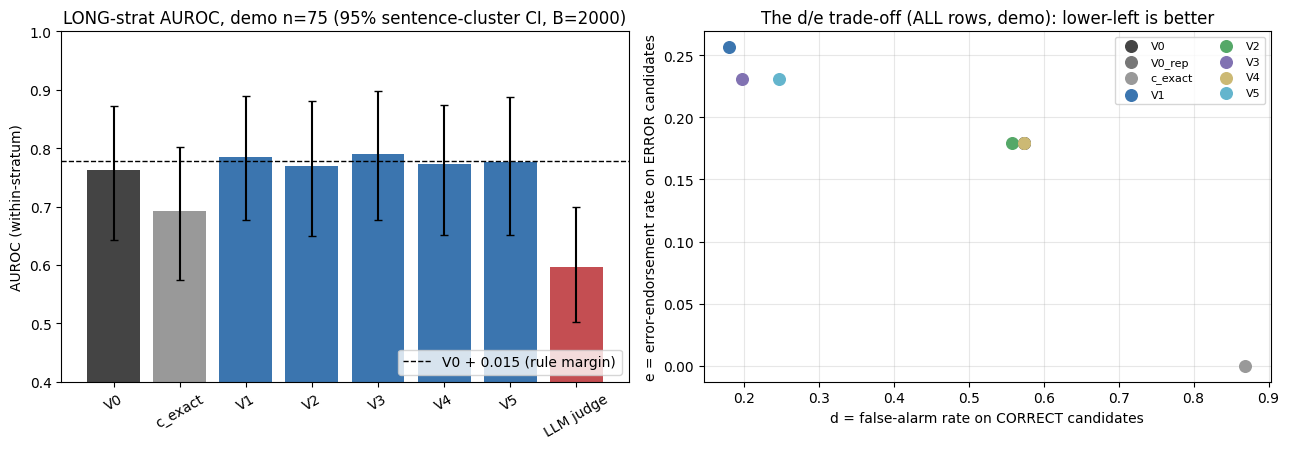

In [14]:
MD = data["metadata"]
# ---- table 1: AUROC per cell (demo) ----
tab = pd.DataFrame(rows_auc).pivot(index="score", columns="cell", values="auroc")[list(CELLS)]
print("AUROC per cell (demo; higher = better at ranking ERROR above CORRECT)")
print(tab.loc[SCORES + JUDGES].round(3).to_string(), "\n")

# ---- table 2: selection rule, demo vs full run ----
cmp = pd.DataFrame({v: {"Δ LONG demo": q[v]["delta_long"], "qualifies demo": q[v]["qualifies"],
                        "Δ LONG full": MD["part_A_qualification"][v]["delta_long"],
                        "qualifies full": MD["part_A_qualification"][v]["qualifies"]} for v in VARIANTS}).T
print(cmp.to_string(), "\n")
print(f"winner  demo: {winner!r}   full: {MD['part_A_winner']!r}")
print(f"stability demo: {stab}\n          full: {MD['part_A_stability']['share_selected']}")
print(f"null share(any qualifies) demo: {null['share_any_variant_qualifies']:.3f}   full: {MD['part_A_null']['share_any_variant_qualifies']:.3f}")

# ---- GG (Part B) on the same rows: g3-style ALL-strat AUROC vs V0 ----
mg = ~np.isnan(P.gg.values)
g_gg, g_v0 = strat_auroc(y[mg], P.gg.values[mg], st[mg]), strat_auroc(y[mg], P.V0_frozen.values[mg], st[mg])
print(f"\nGG ALL-strat demo: {g_gg:.3f} vs V0 {g_v0:.3f} (n={mg.sum()}); full run: GG 0.696 vs V0 0.742 -> {MD['GG_status']}")

# ---- figures ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
cell = "LONG-strat"
names = ["V0_frozen", "c_exact"] + VARIANTS + JUDGES
pts = [A["auroc"][cell][s]["auroc"] for s in names]
lo = [pts[i] - A["auroc"][cell][s]["ci"][0] for i, s in enumerate(names)]
hi = [A["auroc"][cell][s]["ci"][1] - pts[i] for i, s in enumerate(names)]
cols = ["#444444", "#999999"] + ["#3b75af"] * 5 + ["#c44e52"]
ax[0].bar(range(len(names)), pts, yerr=[lo, hi], color=cols, capsize=3)
ax[0].axhline(pts[0] + MARGIN, ls="--", c="k", lw=1, label="V0 + 0.015 (rule margin)")
ax[0].set_xticks(range(len(names)), [n.replace("_frozen", "").replace("judge_cheap_disg", "LLM judge") for n in names], rotation=30)
ax[0].set_ylim(0.4, 1.0)
ax[0].set_ylabel("AUROC (within-stratum)")
ax[0].set_title(f"LONG-strat AUROC, demo n={A['auroc'][cell]['V0_frozen']['n']} (95% sentence-cluster CI, B={B})")
ax[0].legend(loc="lower right")

for s, c in zip(SCORES, ["#444444", "#777777", "#999999", "#3b75af", "#55a868", "#8172b2", "#ccb974", "#64b5cd"]):
    r = ED["ALL"][s]
    ax[1].scatter(r["d"], r["e"], s=70, color=c, label=s.replace("_frozen", ""), zorder=3)
ax[1].set_xlabel("d = false-alarm rate on CORRECT candidates")
ax[1].set_ylabel("e = error-endorsement rate on ERROR candidates")
ax[1].set_title("The d/e trade-off (ALL rows, demo): lower-left is better")
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()